## Setup & Installation



In [ ]:
# ============================================
# SETUP & INSTALLATION
# ============================================

# Install required packages
!pipx install -q ultralytics roboflow

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import os
import glob
import random
import yaml
from pathlib import Path
from collections import Counter

# YOLO imports
from ultralytics import YOLO

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Verify environment
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU device: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected — training will be slow!")
    print("Go to: Runtime → Change runtime type → T4 GPU")

'ultralytics' already seems to be installed. Not modifying existing
installation in '/Users/ledjahalltari/.local/pipx/venvs/ultralytics'. Pass
'--force' to force installation.
'roboflow' already seems to be installed. Not modifying existing installation
in '/Users/ledjahalltari/.local/pipx/venvs/roboflow'. Pass '--force' to force
installation.
PyTorch version: 2.10.0
CUDA available: False
⚠️ No GPU detected — training will be slow!
Go to: Runtime → Change runtime type → T4 GPU


## Importing dataset from Roboflow

In [27]:
from roboflow import Roboflow

rf = Roboflow(api_key="yQJvIZ70VBxNEFuKOEg3")
project = rf.workspace("yousef-ghanem-jzj4y").project("brain-tumor-detection-fpf1f")
version = project.version(1)
dataset = version.download("yolov8")
DATASET_DIR = dataset.location

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to -Brain-Tumor-Detection-1 in yolov8:: 100%|██████████| 46612/46612 [00:03<00:00, 13851.04it/s]


##  Load Pre-trained YOLO26 

In [32]:
# ============================================
# LOAD PRE-TRAINED YOLOv8 MODEL
# ============================================

# yolov8n (nano)    — 3.2M  params, fastest, least accurate
# yolov8s (small)   — 11.2M params
# yolov8m (medium)  — 25.9M params
# yolov8l (large)   — 43.7M params
# yolov8x (xlarge)  — 68.2M params, slowest, most accurate
# We use 'n' (nano) for speed in class.

model_pretrained = YOLO('yolov8n.pt')  # Downloads automatically

# ============================================
# EXPLORE DATASET CLASSES FROM ROBOFLOW
# ============================================
import os
import yaml

# Load dataset config to extract class names
data_yaml_path = os.path.join(DATASET_DIR, 'data.yaml')

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

dataset_classes = data_config['names']   # list of class names
num_classes     = data_config['nc']      # number of classes

print("📋 Model Summary:")
print(f"  Model type: YOLOv8n (Nano)")
print(f"  Task: Object Detection")
print(f"  Pre-trained on: COCO (80 classes)")
print(f"  Will be fine-tuned on: Brain Tumor Detection")

# Remap generic labels if the dataset uses placeholder names
TUMOR_LABEL_REMAP = {
    'label0':  'glioma',
    'label1':  'meningioma',
    'label2':  'pituitary',
    'label3':  'medulloblastoma',
    'label4':  'astrocytoma',
    'label5':  'ependymoma',
    'label6':  'craniopharyngioma',
    'label7':  'schwannoma',
    'label8':  'oligodendroglioma',
    'label9':  'hemangioblastoma',
    'label10': 'brain_metastasis',
    'label11': 'no_tumor',
}

resolved_classes = [
    TUMOR_LABEL_REMAP.get(name, name) for name in dataset_classes
]

print(f"\n🧠 Brain Tumor Dataset Classes ({num_classes} total):")
for i, name in enumerate(resolved_classes):
    raw = dataset_classes[i]
    note = f"  (remapped from '{raw}')" if raw != name else ""
    print(f"  {i}: {name}{note}")

# ============================================
# SHOW DATASET SPLIT STATS
# ============================================
for split in ['train', 'valid', 'test']:
    split_img_dir = os.path.join(DATASET_DIR, split, 'images')
    if os.path.exists(split_img_dir):
        n = len(os.listdir(split_img_dir))
        print(f"\n📂 {split.capitalize()} split: {n} images")

# ============================================
# SHOW TUMOR-RELEVANT CLASS MAPPING
# ============================================
# Since this is a dedicated tumor dataset, ALL classes are tumor-relevant
print(f"\n🔬 Tumor-relevant classes in this dataset:")
for i, name in enumerate(resolved_classes):
    print(f"  Class {i}: {name}")

📋 Model Summary:
  Model type: YOLOv8n (Nano)
  Task: Object Detection
  Pre-trained on: COCO (80 classes)
  Will be fine-tuned on: Brain Tumor Detection

🧠 Brain Tumor Dataset Classes (3 total):
  0: glioma  (remapped from 'label0')
  1: meningioma  (remapped from 'label1')
  2: pituitary  (remapped from 'label2')

📂 Train split: 20330 images

📂 Valid split: 1980 images

📂 Test split: 990 images

🔬 Tumor-relevant classes in this dataset:
  Class 0: glioma
  Class 1: meningioma
  Class 2: pituitary


✅ Found: /Users/ledjahalltari/mini-project-7/notebooks/-Brain-Tumor-Detection-1/train/images/volume_100_slice_100_jpg.rf.a883fc5d01cc9871a65d84128918abfd.jpg
✅ Found: /Users/ledjahalltari/mini-project-7/notebooks/-Brain-Tumor-Detection-1/train/images/volume_100_slice_100_jpg.rf.d2bd330ae527549bc38c8c3cc3e15d1f.jpg


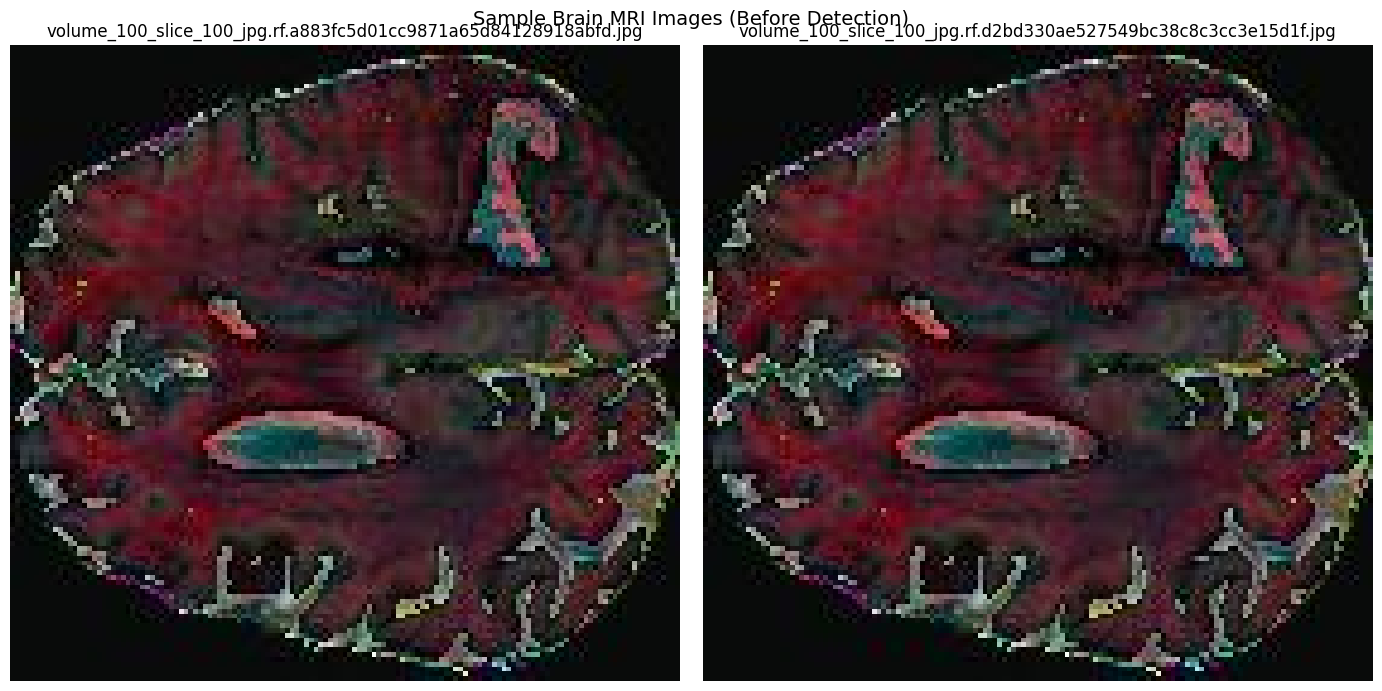

In [33]:
# ============================================
# LOAD SAMPLE BRAIN MRI IMAGES FROM DATASET
# ============================================

# Grab the first 2 images from the train/images folder
# (already downloaded as part of the Roboflow dataset)

train_img_dir = os.path.join(DATASET_DIR, 'train', 'images')

all_images = [
    os.path.join(train_img_dir, f)
    for f in sorted(os.listdir(train_img_dir))
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

sample_images = all_images[:2]   # take first 2, same as traffic example

for path in sample_images:
    print(f"✅ Found: {path}")

# ============================================
# DISPLAY SAMPLE IMAGES
# ============================================

fig, axes = plt.subplots(1, len(sample_images),
                         figsize=(7 * len(sample_images), 7))
if len(sample_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray' if img.mode == 'L' else None)
    ax.set_title(os.path.basename(img_path), fontsize=12)
    ax.axis('off')

plt.suptitle('Sample Brain MRI Images (Before Detection)', fontsize=14)
plt.tight_layout()
plt.show()

## Run Detection & Visualize Results


0: 608x640 1 bus, 42.8ms
1: 608x640 (no detections), 42.8ms
Speed: 1.6ms preprocess, 42.8ms inference, 0.7ms postprocess per image at shape (1, 3, 608, 640)

Image: volume_100_slice_100_jpg.rf.a883fc5d01cc9871a65d84128918abfd.jpg

📦 Detections found: 1
───────────────────────────────────────────────────────
Class                Confidence   Box (x1,y1,x2,y2)
───────────────────────────────────────────────────────
bus                  0.253        [40, 76, 81, 89]


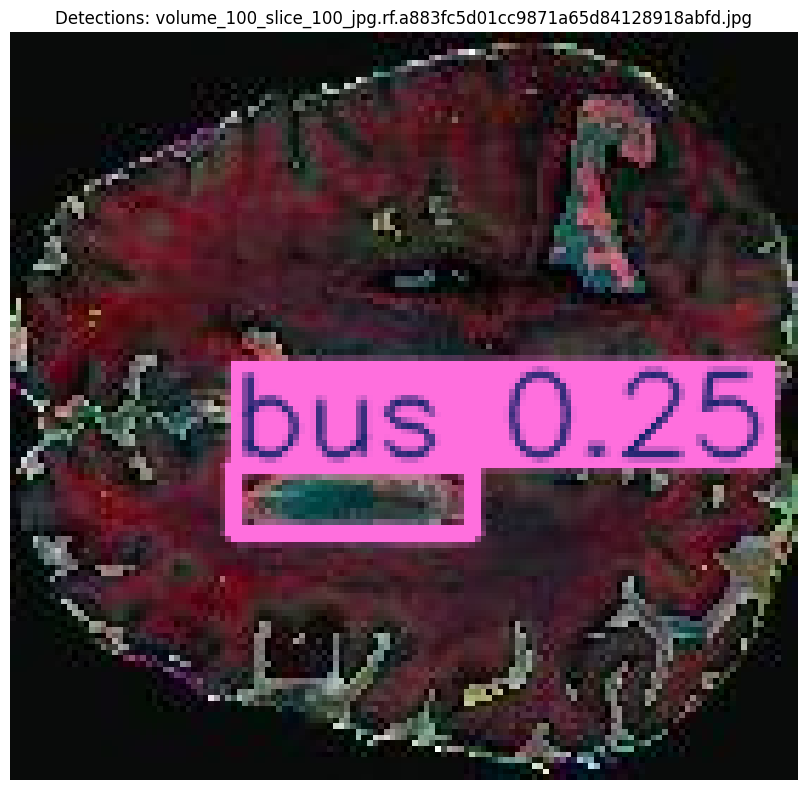


Image: volume_100_slice_100_jpg.rf.d2bd330ae527549bc38c8c3cc3e15d1f.jpg

📦 Detections found: 0
  ⚠️  No detections above confidence threshold.


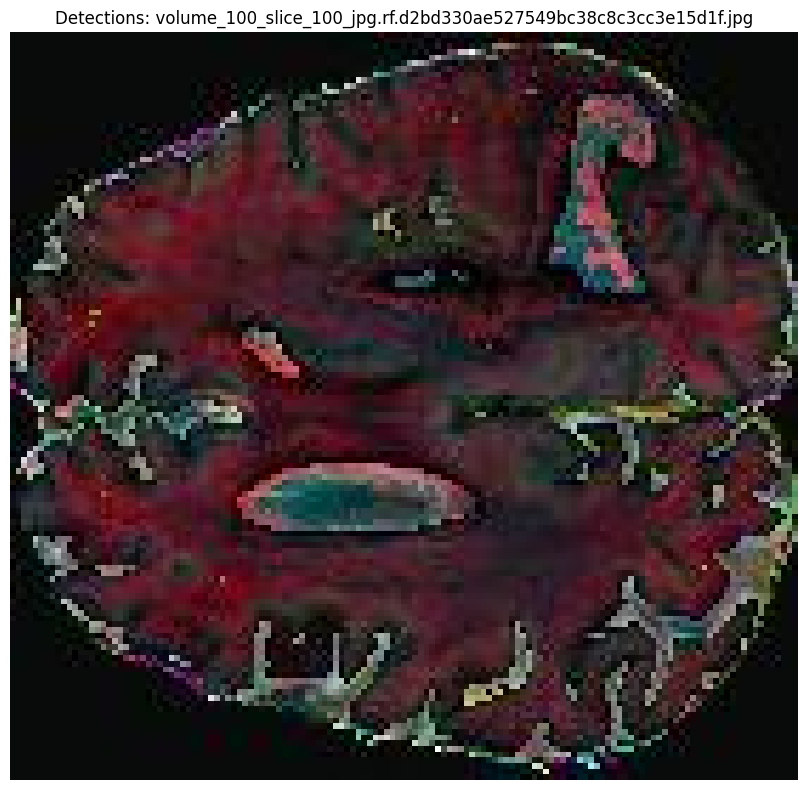

In [34]:
# ============================================
# RUN DETECTION ON SAMPLE BRAIN MRI IMAGES
# ============================================

# conf=0.25 means only show detections with >25% confidence.

results = model_pretrained(sample_images, conf=0.25)

# Display results with detailed breakdown
for i, result in enumerate(results):
    print(f"\n{'=' * 60}")
    print(f"Image: {os.path.basename(sample_images[i])}")
    print(f"{'=' * 60}")

    boxes = result.boxes
    print(f"\n📦 Detections found: {len(boxes)}")

    if len(boxes) == 0:
        print("  ⚠️  No detections above confidence threshold.")
    else:
        print(f"{'─' * 55}")
        print(f"{'Class':<20} {'Confidence':<12} {'Box (x1,y1,x2,y2)'}")
        print(f"{'─' * 55}")
        for box in boxes:
            cls_id    = int(box.cls[0])
            conf      = float(box.conf[0])
            xyxy      = box.xyxy[0].cpu().numpy()
            class_name = model_pretrained.names[cls_id]   # COCO class name
            print(f"{class_name:<20} {conf:<12.3f} "
                  f"[{xyxy[0]:.0f}, {xyxy[1]:.0f}, {xyxy[2]:.0f}, {xyxy[3]:.0f}]")

    # Plot with bounding boxes (or plain image if no detections)
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    annotated = result.plot()          # Returns BGR numpy array
    ax.imshow(annotated[..., ::-1])   # Convert BGR → RGB
    ax.set_title(f"Detections: {os.path.basename(sample_images[i])}", fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

## Explore Confidence Thresholds

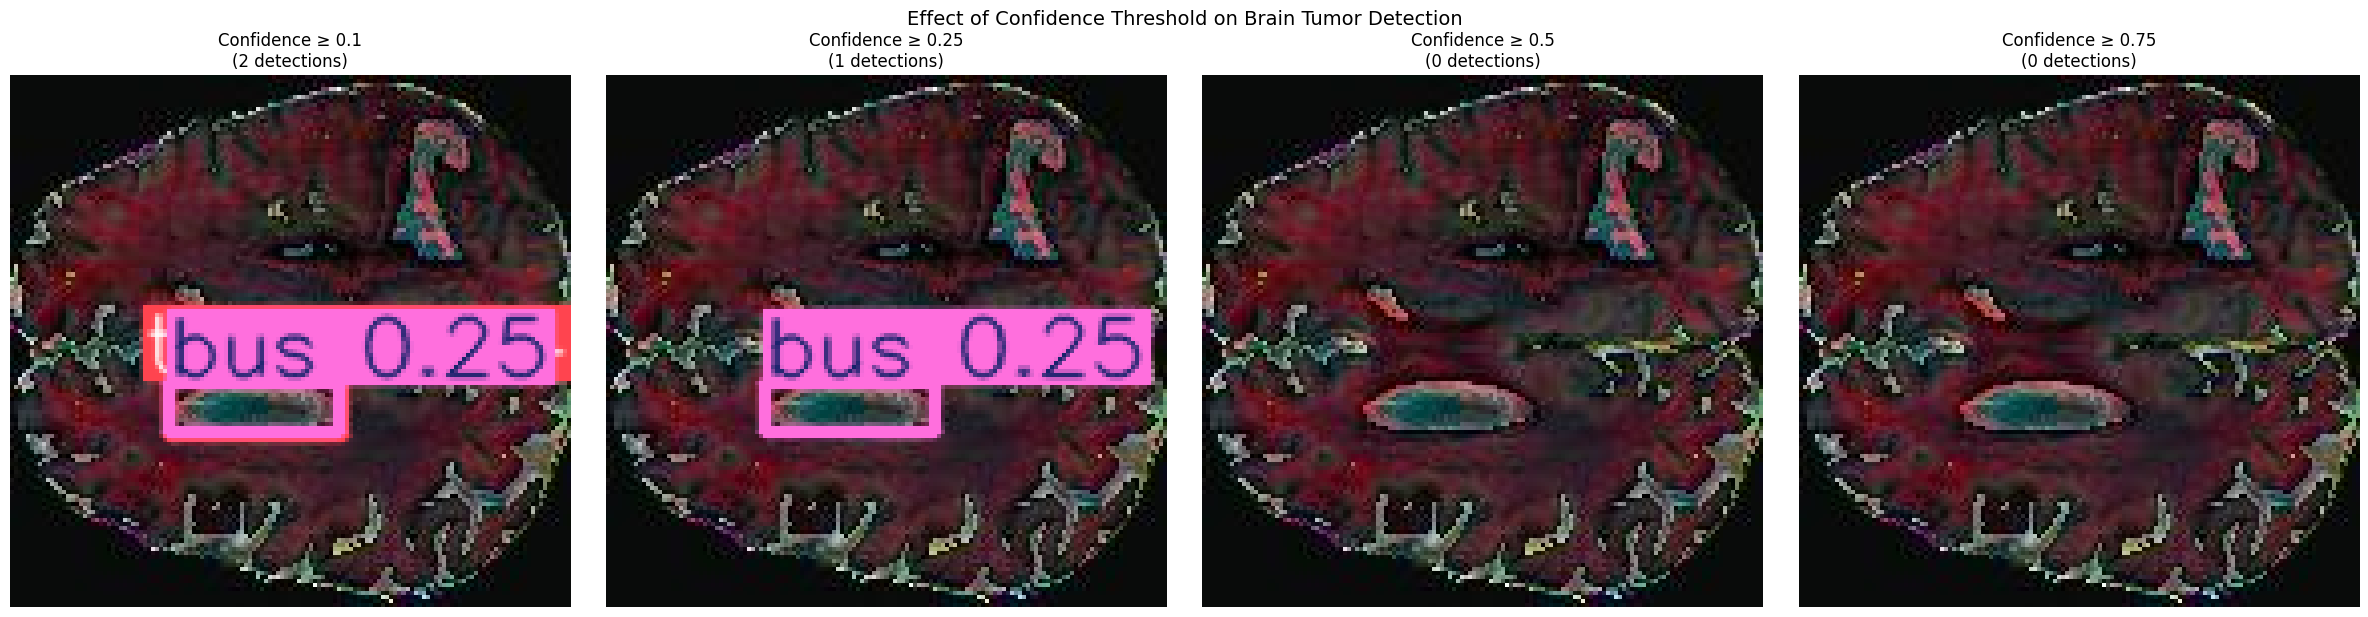

In [36]:
# ============================================
# CONFIDENCE THRESHOLD COMPARISON
# ============================================

test_image = sample_images[0]  # Use first brain MRI sample
thresholds = [0.10, 0.25, 0.50, 0.75]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for ax, thresh in zip(axes, thresholds):
    result = model_pretrained(test_image, conf=thresh, verbose=False)
    annotated = result[0].plot()
    ax.imshow(annotated[..., ::-1])
    n_detections = len(result[0].boxes)
    ax.set_title(f"Confidence ≥ {thresh}\n({n_detections} detections)",
                 fontsize=12)
    ax.axis('off')

plt.suptitle('Effect of Confidence Threshold on Brain Tumor Detection',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



#### 💡 Key Insight for Brain Tumor Detection:
  Low threshold (0.10):  More detections, higher risk of false positives
  
  High threshold (0.75): Fewer detections, only high-confidence predictions
  
  • Clinical screening  → lower threshold (don't miss any potential tumors!)
  
  • Diagnosis support   → higher threshold (precision matters more)

In [ ]:
# ============================================
# FINE-TUNE YOLOv8 ON BRAIN TUMOR DATASET
# ============================================

data_yaml = os.path.join(DATASET_DIR, 'data.yaml')

results = model_pretrained.train(
    data    = data_yaml,       # Path to dataset config
    epochs  = 25,              # Minimum required — increase to 50+ for better results
    imgsz   = 640,             # Standard YOLO input size
    batch   = 16,              # Reduce to 8 if you get out-of-memory errors
    name    = 'brain_tumor_v1',# Run name — saved under runs/detect/
    patience= 10,              # Early stopping if no improvement after 10 epochs
    verbose = True,
)

print("\n✅ Training complete!")
print(f"📁 Results saved to: {results.save_dir}")

Ultralytics 8.4.19 🚀 Python-3.10.19 torch-2.10.0 CPU (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/ledjahalltari/mini-project-7/notebooks/-Brain-Tumor-Detection-1/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=brain_tumor_v1, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, over

In [ ]:
# ============================================
# EVALUATE TRAINED MODEL ON VALIDATION SET
# ============================================

trained_model = YOLO(f"{results.save_dir}/weights/best.pt")

metrics = trained_model.val(
    data    = data_yaml,
    split   = 'val',
    verbose = True,
)

# ============================================
# PRINT EVALUATION METRICS
# ============================================

print("\n" + "=" * 50)
print("        📊 MODEL EVALUATION RESULTS")
print("=" * 50)

print(f"\n{'Metric':<25} {'Value'}")
print(f"{'─' * 40}")
print(f"  {'mAP@50':<23} {metrics.box.map50:.4f}")
print(f"  {'mAP@50-95':<23} {metrics.box.map:.4f}")
print(f"  {'Precision':<23} {metrics.box.mp:.4f}")
print(f"  {'Recall':<23} {metrics.box.mr:.4f}")
print(f"{'─' * 40}")

In [ ]:
# ============================================
# PER-CLASS METRICS
# ============================================

print("\n" + "=" * 60)
print("          📊 PER-CLASS METRICS")
print("=" * 60)
print(f"\n{'Class':<20} {'AP@50':<12} {'Precision':<12} {'Recall'}")
print(f"{'─' * 55}")

for i, class_name in trained_model.names.items():
    ap50      = metrics.box.ap50[i]
    precision = metrics.box.p[i]
    recall    = metrics.box.r[i]
    print(f"  {class_name:<18} {ap50:<12.4f} {precision:<12.4f} {recall:.4f}")

print(f"{'─' * 55}")

# ============================================
# CONFUSION MATRIX
# ============================================

confusion_matrix_path = os.path.join(results.save_dir, 'confusion_matrix.png')

fig, ax = plt.subplots(figsize=(8, 6))
img = Image.open(confusion_matrix_path)
ax.imshow(img)
ax.set_title('Confusion Matrix', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# VISUALIZE 6 PREDICTIONS ON VALIDATION IMAGES
# ============================================

val_img_dir = os.path.join(DATASET_DIR, 'valid', 'images')

val_images = [
    os.path.join(val_img_dir, f)
    for f in sorted(os.listdir(val_img_dir))
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
][:6]

results_val = trained_model(val_images, conf=0.25, verbose=False)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, result, img_path in zip(axes, results_val, val_images):
    annotated = result.plot()
    ax.imshow(annotated[..., ::-1])
    n = len(result.boxes)
    ax.set_title(f"{os.path.basename(img_path)}\n{n} detection(s)", fontsize=10)
    ax.axis('off')

plt.suptitle('YOLOv8 Predictions on Validation Images', fontsize=14)
plt.tight_layout()
plt.show()